# SHAP Values

Model interpretation using SHAP (SHapley Additive exPlanations) to identify which genes drive our classifier's predictions. We'll use the Random Forest model from notebook 04 with TreeSHAP for efficient, exact SHAP value computation. #todo This model could be moved to the src/ folder for better maintainablility and consistency.

## Data Loading & Model Setup
Reproducing the data pipeline and best Random Forest model from notebook 04.

In [120]:
import os
import pandas as pd
import numpy as np
import glob

from pydeseq2.dds import DeseqDataSet

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
SAVE = True
if SAVE:
    OUTPUT_PATH = '/Users/nick/projects/bioinformatics-project/results/shap'
    os.makedirs(OUTPUT_PATH, exist_ok=True)

# Import data
df_metadata = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/metadata.csv', index_col=0)
df_expression = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/expression.csv', index_col=0)

# Data prep — undo log transform to get raw counts
df_expression_rawcounts = (2**df_expression) - 1
df_expression_rawcounts = df_expression_rawcounts.astype(int)

# Filter genes (consistent with notebook 02 and 04)
df_expression_rawcounts_filtered = df_expression_rawcounts[df_expression_rawcounts.columns[(df_expression_rawcounts >= 15).sum(axis=0) >= 15]]
print(f'{df_expression_rawcounts_filtered.shape[1]} genes left after filtering')

# Match indexes
df_metadata = df_metadata.loc[df_expression_rawcounts_filtered.index]

27516 genes left after filtering


In [122]:
# VST normalization
dds = DeseqDataSet(
    counts=df_expression_rawcounts_filtered,
    metadata=df_metadata,
    design='~PAM50'
)

dds.vst()

df_expression_vst = pd.DataFrame(dds.layers['vst_counts'])
df_expression_vst.columns = df_expression_rawcounts_filtered.columns
df_expression_vst.index = df_expression_rawcounts_filtered.index

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.24 seconds.

Fitting dispersions...
... done in 2.74 seconds.



In [123]:
# Train/test split — same parameters as notebook 04
X = df_expression_vst
y = df_metadata['PAM50']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [124]:
# Feature selection — reproduce consensus gene set from notebook 04

# DEG-based
files = sorted(glob.glob('/Users/nick/projects/bioinformatics-project/results/deseq/significant/*.csv'))
genes_DEG = []
for file in files:
    df_temp = pd.read_csv(file, index_col=0)
    genes_DEG = genes_DEG + df_temp.index.to_list()
genes_DEG = set(genes_DEG)

# Variance-based (top 10000)
variances = X_train.var()
genes_variance = set(variances.nlargest(10000).index)

# Random Forest importance (top 5000)
rf_features = RandomForestClassifier(n_estimators=100, random_state=1)
rf_features.fit(X_train, y_train)
rf_features_result = pd.Series(
    data=rf_features.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(5000)

# Consensus — genes selected by all 3 methods (sorted for reproducibility)
gene_sets = {'DEG': genes_DEG, 'Variance': genes_variance, 'RF': set(rf_features_result.index)}
all_genes = set().union(*gene_sets.values())
gene_counts = {gene: sum(gene in s for s in gene_sets.values()) for gene in all_genes}
consensus_genes = sorted([gene for gene, count in gene_counts.items() if count >= 3])

print(f'Consensus feature set: {len(consensus_genes)} genes')

X_train_consensus = X_train[consensus_genes]
X_test_consensus = X_test[consensus_genes]

Consensus feature set: 1734 genes


In [125]:
# Retrain Random Forest with best params from notebook 04
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=1
)

rf_model.fit(X_train_consensus, y_train)

print(f'Classes: {rf_model.classes_}')
print(f'Training accuracy: {rf_model.score(X_train_consensus, y_train):.4f}')
print(f'Test accuracy: {rf_model.score(X_test_consensus, y_test):.4f}')

Classes: ['Basal' 'Her2' 'LumA' 'LumB' 'Normal']
Training accuracy: 1.0000
Test accuracy: 0.9000


# SHAP Analysis
Now that we have our trained Random Forest model and test data, we can compute SHAP values to understand which genes drive predictions for each subtype.

## Compute SHAP Values

In [126]:
# Create explainer and compute SHAP values
shap_explainer = shap.TreeExplainer(rf_model)
shap_values = shap_explainer(X_test_consensus)
print(shap_values.shape)

(110, 1734, 5)


In [127]:
# Print indexes for classes for reference
class_to_idx = {cls: i for i, cls in enumerate(rf_model.classes_)}
for cls, i in class_to_idx.items():
    print(f'Class: {cls} | Index: {i}')

Class: Basal | Index: 0
Class: Her2 | Index: 1
Class: LumA | Index: 2
Class: LumB | Index: 3
Class: Normal | Index: 4


In [128]:
# Build a display copy of the SHAP values with readable gene symbols
df_gene_map = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/gene_map.csv')
ensg_to_symbol = dict(zip(df_gene_map['gene_id'], df_gene_map['symbol'].fillna(df_gene_map['gene_id'])))

# Build unique symbol list (append .2, .3, ... to duplicate symbols)
seen = {}
unique_symbols = []
for ensg in shap_values.feature_names:
    sym = ensg_to_symbol.get(ensg, ensg)
    if sym in seen:
        seen[sym] += 1
        sym = f"{sym}.{seen[sym]}"
    else:
        seen[sym] = 1
    unique_symbols.append(sym)

# Named shap values for plotting
shap_values_named = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=shap_values.data,
    feature_names=unique_symbols,
)

# Created named df using unique symbols
X_test_named = X_test_consensus.copy()
X_test_named.columns = unique_symbols

## Step 2: Summary Plots (per subtype)
Now, I will create a summary plot of the shap values.
### Interpretation
- each row is a gene
- each dot is a sample
- shap values are plotted on the x axis, positive shap values indicate that the gene in that sample is pushing that sample toward the plotted subtype
- the color indicates the expression value
    - red = higher expression
    - blue = lower expression

#todo add other subtype plots

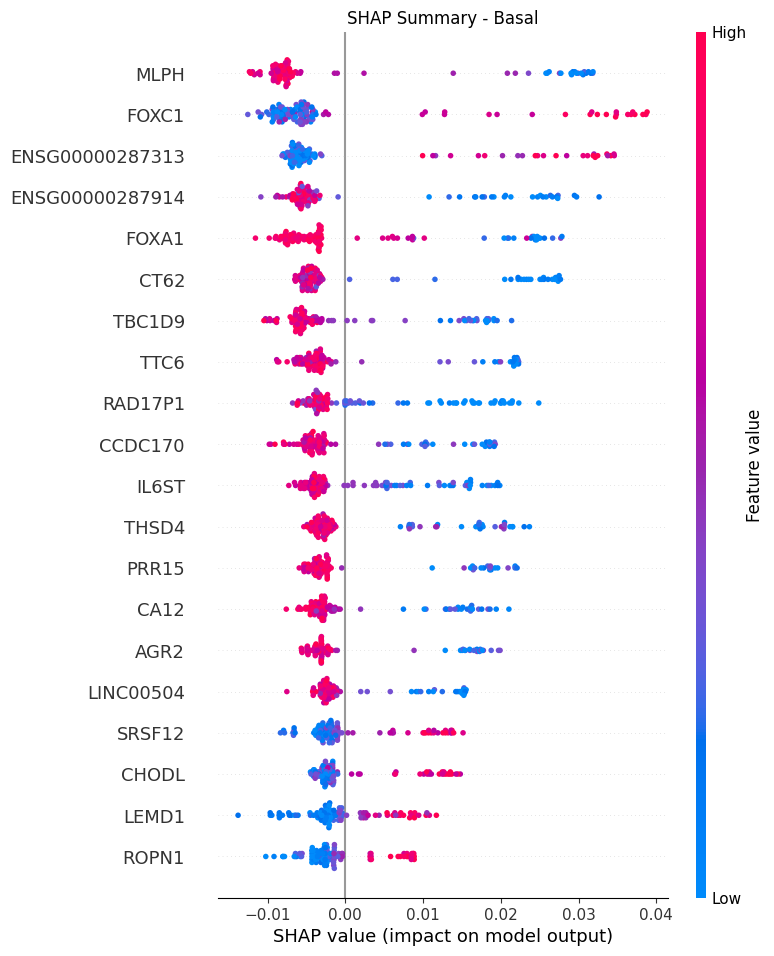

In [129]:
# Summary plot — Basal
shap.summary_plot(shap_values_named[:, :, 0], X_test_named, show=False)
plt.title('SHAP Summary - Basal')
plt.show()

## Step 3: Bar Plot (global feature importance).

Create a global feature importance to identify the genes globally that most contribute to the classifcation of different classes.

Since this is a global plot, genes that may be very important in distingusihing two classes may have been averaged out and appear insignificant in the global average.

#todo it would be nice to do one for each subtype, this would produce a much more compelling figure

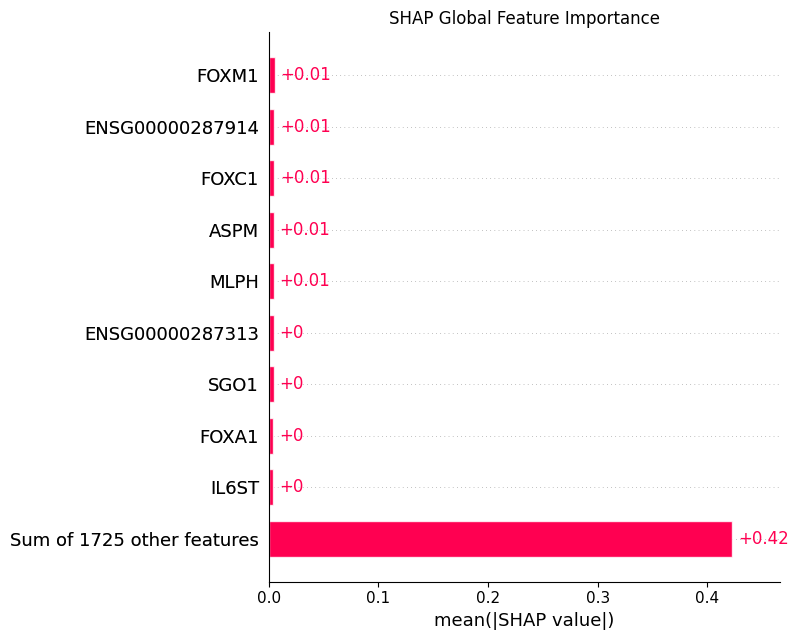

In [130]:
# Global bar plot
# aggregate SHAP values across classes for a single global importance per feature
shap_values_global = shap.Explanation(
    values=np.abs(shap_values_named.values).mean(axis=2),
    base_values=np.zeros(shap_values_named.values.shape[0]),
    data=shap_values_named.data,
    feature_names=shap_values_named.feature_names,
)

shap.plots.bar(shap_values_global, show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.show()

## Step 4: Waterfall Plots (decompose individual predictions)

We will be using a waterfall plot the effect of the most impactful genes on making a classification. These will plot and help explain a single prediction, so the following are examples, but within the context of an active study, we could use these on individual tissues or cells of interest (depending on data).

Example waterfall plots below:
- A correctly classified Basal sample
- A Her2 sample
- A misclassified sample

In [131]:
# Find sample indices for waterfall plots
y_pred = rf_model.predict(X_test_consensus)

# Create boolean masks
mask_basal_correct = (y_test.values == 'Basal') & (y_pred == 'Basal')
mask_her2_correct = (y_test.values == 'Her2') & (y_pred == 'Her2')
mask_misclasified = y_test.values != y_pred

# First iloc for each mask
idx_basal_correct = np.where(mask_basal_correct)[0][0]
idx_her2_correct = np.where(mask_her2_correct)[0][0]
idx_misclassified = np.where(mask_misclasified)[0][0]

# Details on chosen samples
for label, idx in [
    ('Correct Basal', idx_basal_correct),
    ('Correct Her2', idx_her2_correct),
    ('Misclassified', idx_misclassified)
    ]:
    probs = rf_model.predict_proba(X_test_consensus.iloc[[idx]])[0].round(3)
    print(f'{label} | iloc={idx} | true={y_test.values[idx]} | pred={y_pred[idx]}')
    print(f'  probs: {dict(zip(rf_model.classes_, probs))}\n')

Correct Basal | iloc=14 | true=Basal | pred=Basal
  probs: {'Basal': np.float64(0.84), 'Her2': np.float64(0.03), 'LumA': np.float64(0.07), 'LumB': np.float64(0.03), 'Normal': np.float64(0.03)}

Correct Her2 | iloc=1 | true=Her2 | pred=Her2
  probs: {'Basal': np.float64(0.14), 'Her2': np.float64(0.6), 'LumA': np.float64(0.09), 'LumB': np.float64(0.15), 'Normal': np.float64(0.02)}

Misclassified | iloc=2 | true=Her2 | pred=LumA
  probs: {'Basal': np.float64(0.21), 'Her2': np.float64(0.23), 'LumA': np.float64(0.24), 'LumB': np.float64(0.22), 'Normal': np.float64(0.1)}



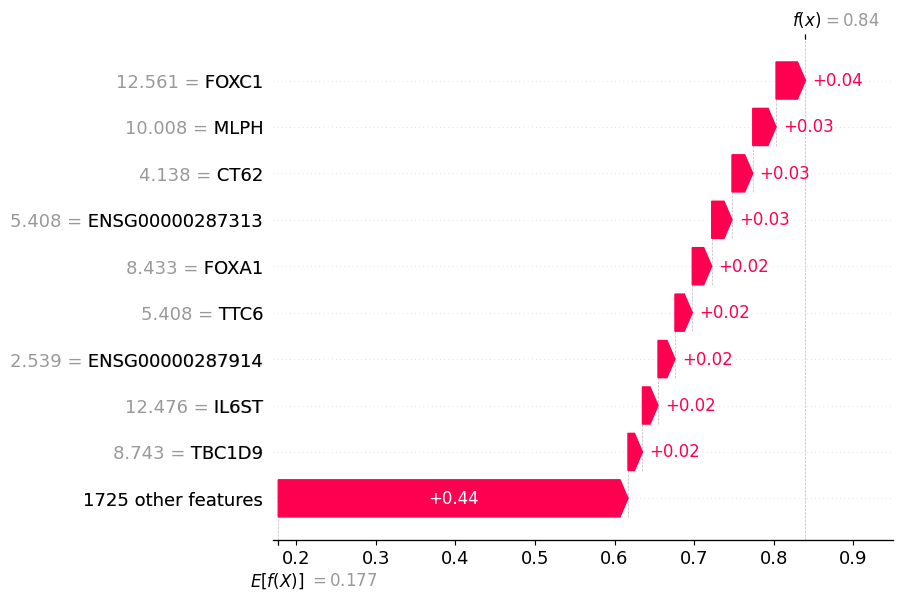

In [132]:
# Waterfall — correctly classified Basal
shap.plots.waterfall(shap_values_named[idx_basal_correct, :, class_to_idx['Basal']])

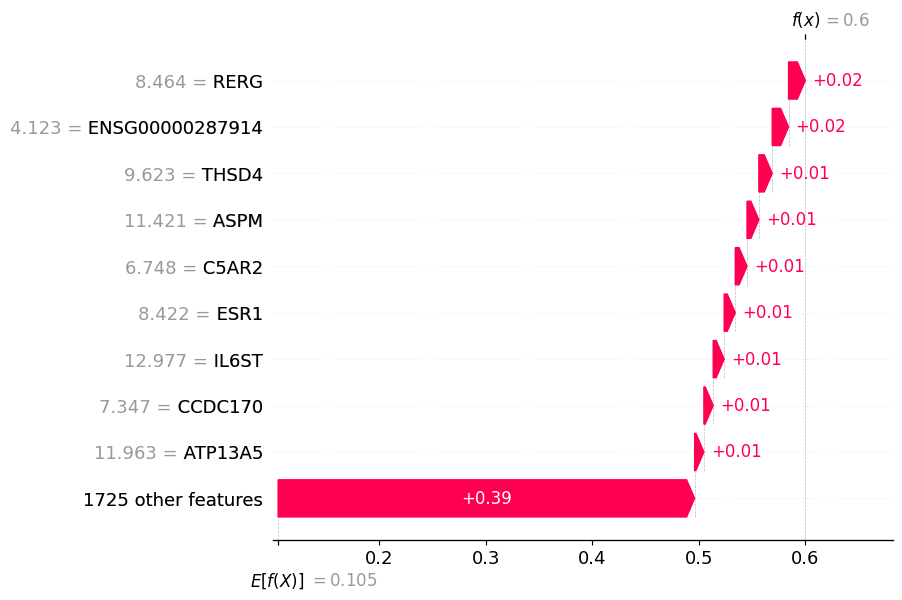

In [133]:
# Waterfall — correctly classified Her2
shap.plots.waterfall(shap_values_named[idx_her2_correct, :, class_to_idx['Her2']])

Predicted-class view: explaining why model chose LumA


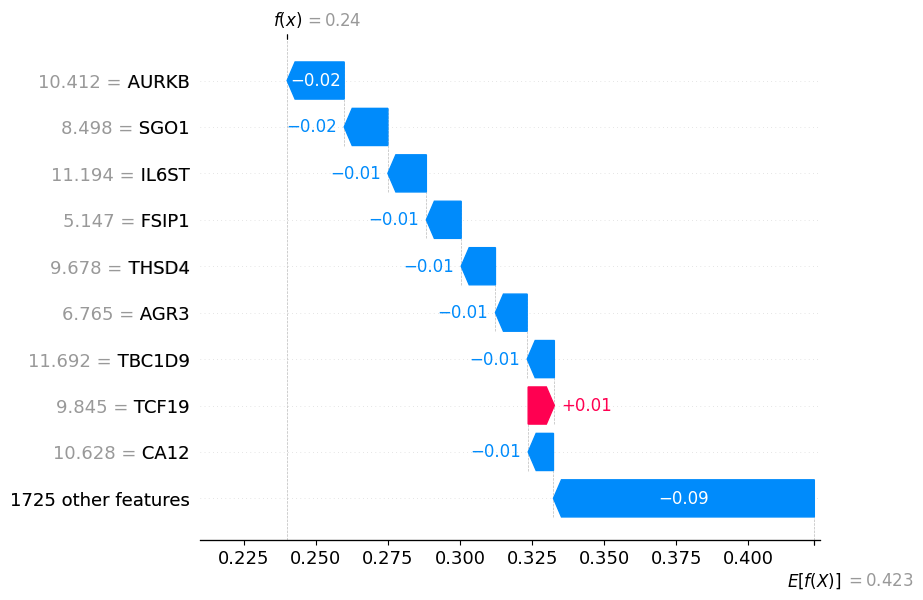

True-class view: explaining Her2 probability


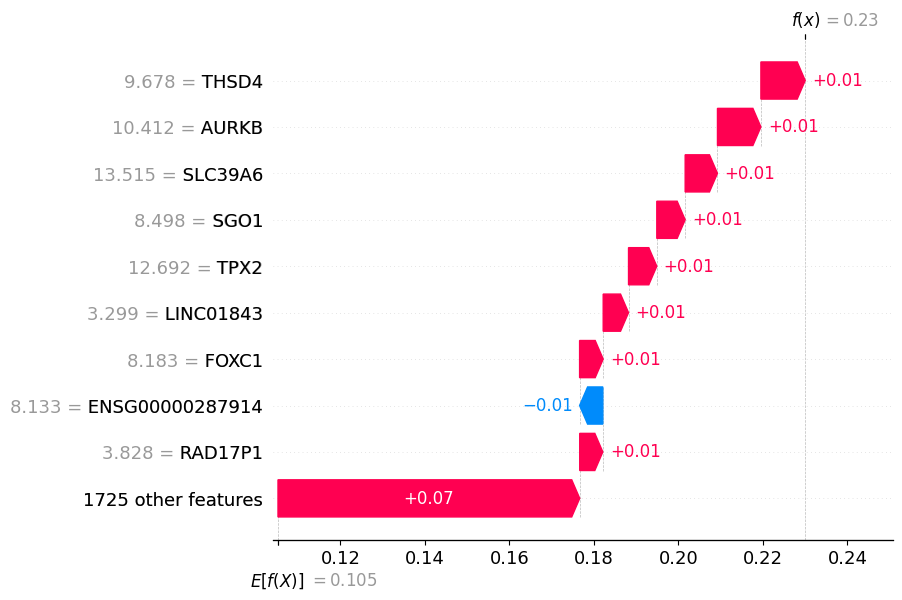

In [134]:
# Waterfall — misclassified sample
true_label = y_test.values[idx_misclassified]
pred_label = y_pred[idx_misclassified]

# View 1: what convinced the model to pick the wrong class
print(f'Predicted-class view: explaining why model chose {pred_label}')
shap.plots.waterfall(shap_values_named[idx_misclassified, :, class_to_idx[pred_label]])

# View 2: what evidence the model was missing for the true class
print(f'True-class view: explaining {true_label} probability')
shap.plots.waterfall(shap_values_named[idx_misclassified, :, class_to_idx[true_label]])

## Step 5: Dependence Plots

Dependence plots help visualize the relationship between expression (x-axis) and the SHAP value (y-axis). I added another gene to the visualizations with color to aid in identifying potential interactions between genes; not specifying color automatically picks the strongest interacting feature.

In [135]:
# Dependence plots for top genes
def dependence_plot(shap_values, gene, cls):
    '''
    shap_values: full shap_values_named (sliced into 1D Explanation)
    gene (str): gene name
    cls (str): class/subtype (LumA, LumB, Her2, Basal, Normal)
    '''
    
    cls_idx = class_to_idx[cls]

    shap_expl_1d = shap_values[:, gene, cls_idx]
    shap.plots.scatter(shap_expl_1d, color=shap_values[:, :, cls_idx]) # can specify specific gene in index 1 of shap_values used for color

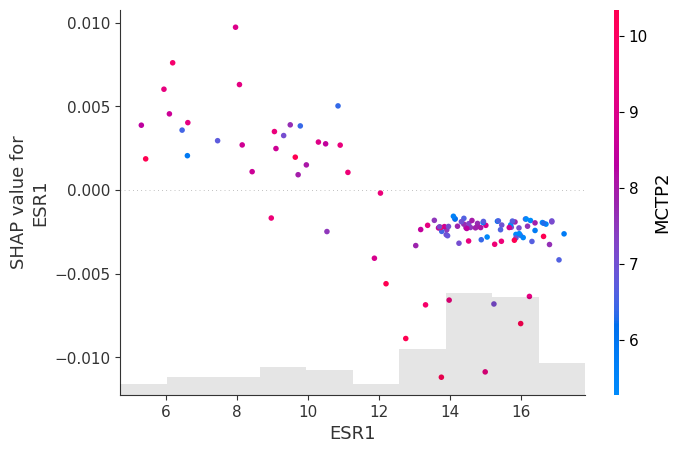

In [136]:
dependence_plot(shap_values_named, 'ESR1', 'Basal')

### Interpreting the dependence plot
- x-axis: gene expression value (VST normalized)
- y-axis: SHAP value for gene
- point: one sample
- color: interacting feature's value
- histogram: distribution of gene expression values

For the above dependence plot, we can see that low expression of ESR1 pushes the model positively toward the classification of Basal for that sample. Where, higher expression of ESR1 pushed the model away from Basal as a classification of that sample, but less strongly. The relationship between the SHAP value and the expression can be even more clearly seen in some of the upcoming plots I did on "top genes", the genes most important to the classifcation of a class/subtype.

As for the color, we can use this to look for interactions between genes. For this analysis, I will not focus on this, but looking for color differences between groups of points or even distribution of colors could show interactions or non-interactions between genes.

In [137]:
def top_genes_dependence_plots(shap_values, cls):
    '''
    Outputs 5 dependence plots for the top 5 genes in a given class

    shap_values: full shap_values_named (sliced into 1D Explanation)
    gene (str): gene name
    cls (str): class/subtype (LumA, LumB, Her2, Basal, Normal)
    '''
    cls_idx = class_to_idx[cls]
    importance = np.abs(shap_values[:,:,cls_idx].values).mean(axis=0)

    top_indexs = np.argsort(importance)[::-1][:5]
    top_genes = [shap_values.feature_names[i] for i in top_indexs]
    
    for gene in top_genes:
        shap.plots.scatter(
            shap_values[:, gene, cls_idx],
            color = shap_values[:, :, cls_idx],
            show = False
        )
        plt.title(f'SHAP Dependence - {gene} ({cls})')
        plt.show()

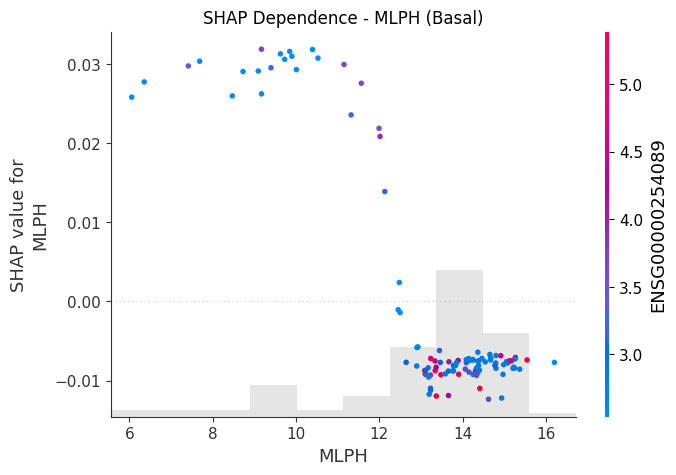

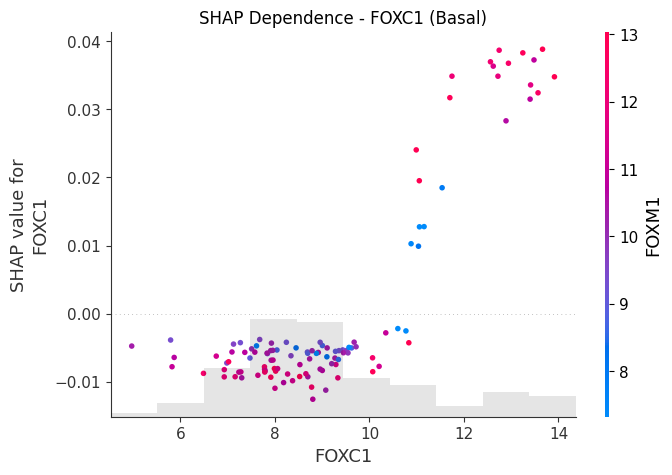

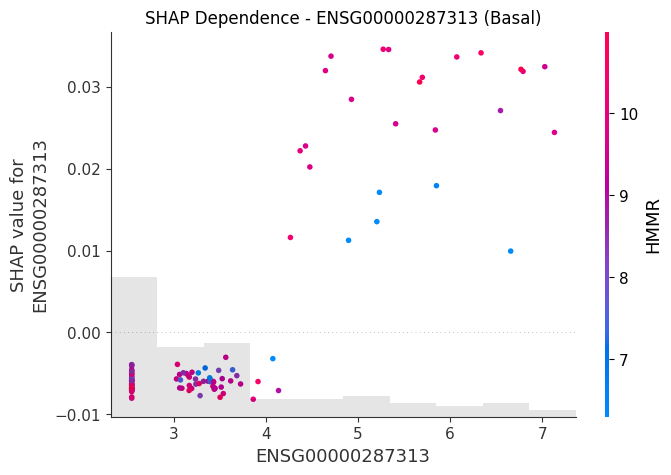

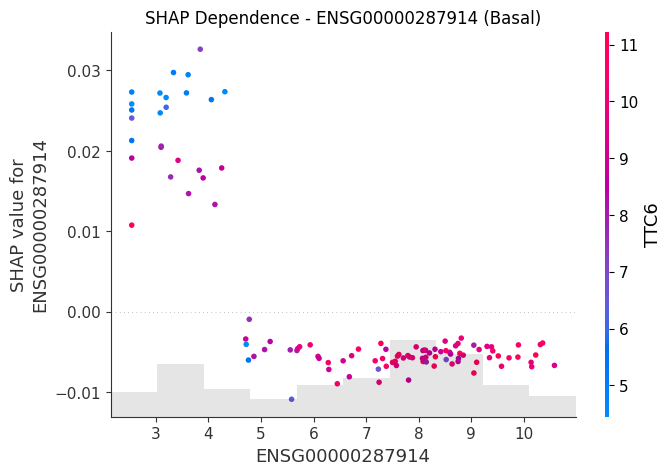

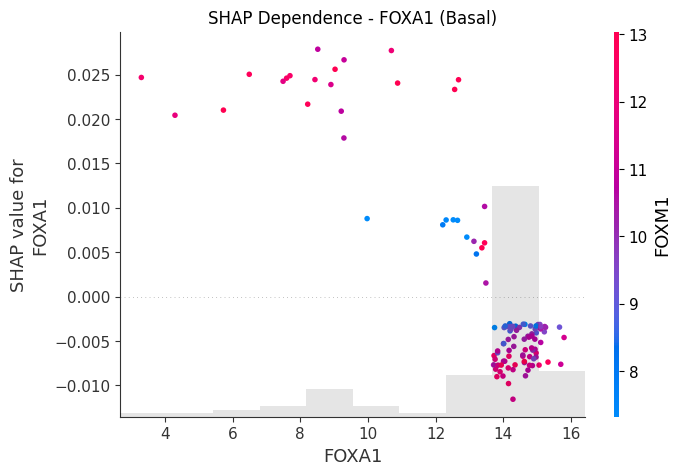

In [138]:
top_genes_dependence_plots(shap_values_named, 'Basal')

## Step 6: SHAP vs DEG Comparison
Comparing the top SHAP genes with the DEG genes we calculated in notebook 3 can let us see the overlap of the statistically significant genes that also drive decisions in the model.

Compare the top SHAP genes with your DEG gene set (`genes_DEG` is already loaded). Use set operations to find:
- **Overlap:** `set(top_shap_genes) & genes_DEG` — validated by both methods
- **SHAP-only:** `set(top_shap_genes) - genes_DEG` — possibly important through nonlinear/interaction effects
- **DEG-only:** `genes_DEG - set(top_shap_genes)` — statistically significant but possibly redundant with correlated genes

To get the top SHAP genes, extract mean |SHAP| per feature from the Explanation object.

In [139]:
# SHAP vs DEG comparison
# Calculate global importance
importance = np.abs(shap_values.values).mean(axis=(0,2)) # axis does mean over classes and samples, leaving us with 1d array

n = 100
top_indices = np.argsort(importance)[::-1][:n]
top_shap_genes = set(np.array(shap_values.feature_names)[top_indices])

overlap = top_shap_genes & genes_DEG
shap_only = top_shap_genes - genes_DEG
deg_only = genes_DEG - top_shap_genes

print(f'Top SHAP genes in DEG set: {len(overlap)}/{len(top_shap_genes)} ({len(overlap)/len(top_shap_genes):.1%})')

for ensg in sorted(overlap):
    print(f'    {ensg_to_symbol.get(ensg, ensg)}')

Top SHAP genes in DEG set: 100/100 (100.0%)
    DEPDC1
    DEPDC1B
    FOXC1
    BCAS1
    ROPN1
    ASPM
    PRR11
    CA12
    GTSE1
    RAD54L
    TPX2
    BIRC5
    ESR1
    CDC45
    CDC6
    SOX10
    XBP1
    CDKN3
    GINS1
    MYBL2
    SACK1D
    SFRP1
    AGR2
    GATA3
    TBC1D9
    NEIL3
    NCAPG
    FOXM1
    RAD51AP1
    MLPH
    NEK2
    CENPF
    CCDC170
    NCAPH
    KIF18A
    SPDEF
    DLGAP5
    KRT17
    FOXA1
    SGO1
    CCNB1
    IL6ST
    RERG
    C5AR2
    TROAP
    ESPL1
    TCF19
    KIF23
    KIF11
    CEP55
    CENPE
    TTC6
    SLC39A6
    PLK4
    PM20D2
    MKI67
    FSIP1
    SRSF12
    CHODL
    SKA1
    PGAP3
    RACGAP1
    NEK10
    KIF15
    PLK1
    CDT1
    GP2
    CDK1
    SHCBP1
    ID4
    AGR3
    GPR160
    EXO1
    PRR15
    AURKB
    LOC124904701
    RGMA
    KPNA2
    IQGAP3
    LEMD1
    KIF18B
    ERCC6L
    ATP13A5
    THSD4
    ACADSB
    PPP1R14C
    EEF1DP5
    CT62
    ENSG00000225889
    GTF2IP7
    RAD17P1
    ENSG0000023382

#todo doing SHAP values per class is probably best and something that would make this a whole lot more robust, but we have built the foundation to be able to idenify biologically meaningful genes per class with minimal modification. We are also able to look at the interactions between genes using the dependence plots.

I mentioned almost this same issue in step 3. I think that this would be much more convincing than using the global numbers when trying to understand the biological interactions.